# EDA — 4 dataset biển số VN đã chọn (Tuần 2)

Notebook này để xem thử các dataset biển số nhóm định dùng, xem số lượng, chất lượng nhãn, ánh sáng, bối cảnh chụp có ổn không trước khi quyết định dùng làm nền train. A3/A4/A1 là nền chính đã chốt cho Tuần 2 (chương "Thu thập và xử lý dữ liệu"); A1/A2 là top 2 đang xem xét riêng cho bài toán detect vùng biển số.

| Ký hiệu | Dataset | Nguồn | License |
|---|---|---|---|
| A1 | Vietnam License Plate Segment Datasets (duydieunguyen) | Kaggle | Unknown — cần hỏi lại tác giả |
| A2 | Vietnamese Car License Plate (Cuong Ta) | Roboflow Universe | Public Domain (CC0) |
| A3 | vietnamese-license-plate-tptd0 (school-fuhih) | Roboflow Universe | CC BY 4.0 |
| A4 | Motorcycle License Plate (Hanoi University of Industry) | Roboflow Universe | MIT |

Quá trình tìm và so sánh 16 dataset (không chỉ 4 cái này) ghi ở `docs/research/2026-07-30-parking-vehicle-plate-datasets.md`. Ký hiệu A1–A4 ở trên khớp với thứ tự ưu tiên hiện tại trong note đó.

Chạy local, không cần GPU/Colab vì chỉ tải + phân tích, không train. Cần có:
- venv `.venv/` (repo root), cài theo `requirements-eda.txt` cạnh notebook này.
- file `.env` ở repo root, có dòng `ROBOFLOW_API_KEY=<key của bạn>` (không commit, đã có trong `.gitignore`).
- `~/.kaggle/kaggle.json` đã cấu hình sẵn cho Kaggle API.

Ảnh tải về nằm ở `data/raw/` (gitignored, không đẩy ảnh thật lên repo).


In [1]:
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

random.seed(42)
np.random.seed(42)

REPO_ROOT = Path.cwd().resolve().parents[2] if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_RAW = REPO_ROOT / "data" / "raw"
FIG_DIR = REPO_ROOT / "docs" / "report" / "figures"
OUT_DIR = REPO_ROOT / "docs" / "research" / "eda_outputs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(REPO_ROOT / ".env")
print("Repo root:", REPO_ROOT)
print("Data raw dir:", DATA_RAW)


Repo root: E:\Learn\UIT\UIT2026-DoAnCuoiKi
Data raw dir: E:\Learn\UIT\UIT2026-DoAnCuoiKi\data\raw


## 1. Tải dữ liệu

Mỗi cell check xem thư mục đích đã có chưa, có rồi thì bỏ qua, không tải lại — chạy lại notebook không sợ tải trùng.

In [2]:
# A4 - Motorcycle License Plate (Hanoi University of Industry) — Roboflow, MIT
from roboflow import Roboflow

target = DATA_RAW / "haui_motorcycle_plate"
if target.exists():
    print("Đã tồn tại, bỏ qua tải lại:", target)
else:
    rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
    project = rf.workspace("hanoi-university-of-industry").project("motorcycle-license-plate")
    project.version(2).download("yolov8", location=str(target))


Đã tồn tại, bỏ qua tải lại: E:\Learn\UIT\UIT2026-DoAnCuoiKi\data\raw\haui_motorcycle_plate


In [3]:
# A3 - vietnamese-license-plate-tptd0 (school-fuhih) — Roboflow, CC BY 4.0
target = DATA_RAW / "school_fuhih_vn_plate"
if target.exists():
    print("Đã tồn tại, bỏ qua tải lại:", target)
else:
    rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
    project = rf.workspace("school-fuhih").project("vietnamese-license-plate-tptd0")
    project.version(1).download("yolov8", location=str(target))


Đã tồn tại, bỏ qua tải lại: E:\Learn\UIT\UIT2026-DoAnCuoiKi\data\raw\school_fuhih_vn_plate


In [4]:
# A1 - Vietnam License Plate Segment Datasets (duydieunguyen) — Kaggle, license Unknown (verify with author)
import subprocess

target = DATA_RAW / "kaggle_vn_plate_segment"
if target.exists() and any(target.iterdir()):
    print("Đã tồn tại, bỏ qua tải lại:", target)
else:
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", "duydieunguyen/licenseplates",
         "-p", str(target), "--unzip"],
        check=True,
    )


Đã tồn tại, bỏ qua tải lại: E:\Learn\UIT\UIT2026-DoAnCuoiKi\data\raw\kaggle_vn_plate_segment


In [5]:
# A2 - Vietnamese Car License Plate (Cuong Ta) — Roboflow, Public Domain (CC0)
target = DATA_RAW / "cuongta_vn_car_plate"
if target.exists():
    print("Đã tồn tại, bỏ qua tải lại:", target)
else:
    rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
    project = rf.workspace("cuong-ta-ulxex").project("vietnamese-car-license-plate")
    project.version(1).download("yolov8", location=str(target))


Đã tồn tại, bỏ qua tải lại: E:\Learn\UIT\UIT2026-DoAnCuoiKi\data\raw\cuongta_vn_car_plate


## 2. Cấu hình dataset + hàm tiện ích

Mỗi dataset có layout thư mục và format nhãn hơi khác nhau (kiểm tra tay sau khi tải xong):
- A4, A3, A2 (Roboflow export chuẩn YOLOv8): `<split>/images/`, `<split>/labels/`, nhãn bbox `class xc yc w h` (normalized).
- A1 (Kaggle): `images/<split>/`, `labels/<split>/`, nhãn polygon `class x1 y1 x2 y2 x3 y3 x4 y4` (4 góc biển, normalized) — 2 class `BSD` (biển dài / 1 hàng) và `BSV` (biển vuông / 2 hàng).

In [6]:
DATASETS = {
    "haui_motorcycle_plate": {
        "label": "A4 - Motorcycle plate (HaUI)",
        "license": "MIT",
        "splits": ["train", "valid", "test"],
        "format": "bbox",
        "class_names": {0: "license-plate"},
    },
    "school_fuhih_vn_plate": {
        "label": "A3 - vietnamese-license-plate (school-fuhih)",
        "license": "CC BY 4.0",
        "splits": ["train", "valid", "test"],
        "format": "bbox",
        "class_names": {0: "plate"},
    },
    "kaggle_vn_plate_segment": {
        "label": "A1 - Vietnam License Plate Segment (Kaggle, duydieunguyen)",
        "license": "Unknown (verify with author)",
        "splits": ["train", "val"],
        "format": "polygon",
        "class_names": {0: "BSD (bien dai / 1 hang)", 1: "BSV (bien vuong / 2 hang)"},
    },
    "cuongta_vn_car_plate": {
        "label": "A2 - Vietnamese Car License Plate (Cuong Ta)",
        "license": "Public Domain (CC0)",
        "splits": ["train", "valid", "test"],
        "format": "bbox",
        "class_names": {0: "plate"},
    },
}


def image_label_pairs(dataset_key, cfg):
    """Yields (split, image_path, label_path_or_None) for every image in a dataset."""
    pairs = []
    for split in cfg["splits"]:
        if dataset_key == "kaggle_vn_plate_segment":
            img_dir = DATA_RAW / dataset_key / "images" / split
            lbl_dir = DATA_RAW / dataset_key / "labels" / split
        else:
            img_dir = DATA_RAW / dataset_key / split / "images"
            lbl_dir = DATA_RAW / dataset_key / split / "labels"
        if not img_dir.exists():
            continue
        for img_path in img_dir.iterdir():
            if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png"):
                continue
            lbl_path = lbl_dir / (img_path.stem + ".txt")
            pairs.append((split, img_path, lbl_path if lbl_path.exists() else None))
    return pairs


def parse_label_file(path, fmt):
    """Returns list of (class_id, normalized_box_area_ratio) per annotated object."""
    rows = []
    if path is None:
        return rows
    text = path.read_text(encoding="utf-8", errors="ignore")
    for line in text.splitlines():
        parts = line.strip().split()
        if not parts or not parts[0].lstrip("-").isdigit():
            continue  # skip Roboflow's license-header .txt files, blank lines
        cls = int(parts[0])
        vals = list(map(float, parts[1:]))
        if fmt == "bbox" and len(vals) >= 4:
            area = vals[2] * vals[3]
        elif fmt == "polygon" and len(vals) >= 8:
            xs, ys = vals[0::2], vals[1::2]
            area = (max(xs) - min(xs)) * (max(ys) - min(ys))
        else:
            continue
        rows.append((cls, area))
    return rows


ALL_PAIRS = {key: image_label_pairs(key, cfg) for key, cfg in DATASETS.items()}
for key, pairs in ALL_PAIRS.items():
    print(f"{key}: {len(pairs)} ảnh")


haui_motorcycle_plate: 1748 ảnh
school_fuhih_vn_plate: 8357 ảnh
kaggle_vn_plate_segment: 4578 ảnh
cuongta_vn_car_plate: 8254 ảnh


## 3. Số lượng ảnh theo split

In [7]:
split_rows = [{"dataset": k, "split": s} for k, pairs in ALL_PAIRS.items() for s, _, _ in pairs]
split_df = pd.DataFrame(split_rows)

split_pivot = split_df.groupby(["dataset", "split"]).size().unstack(fill_value=0)
split_pivot["total"] = split_pivot.sum(axis=1)
split_pivot


split,test,train,val,valid,total
dataset,,,,,
cuongta_vn_car_plate,0,5777,0,2477,8254
haui_motorcycle_plate,177,1397,0,174,1748
kaggle_vn_plate_segment,0,3433,1145,0,4578
school_fuhih_vn_plate,832,5845,0,1680,8357


## 4. Phân bố class (số lượng object gán nhãn)

In [8]:
class_rows = []
for key, cfg in DATASETS.items():
    for split, img_path, lbl_path in ALL_PAIRS[key]:
        for cls, area in parse_label_file(lbl_path, cfg["format"]):
            class_rows.append({
                "dataset": key,
                "split": split,
                "class_id": cls,
                "class_name": cfg["class_names"].get(cls, str(cls)),
                "box_area_ratio": area,
            })
class_df = pd.DataFrame(class_rows)

class_counts = class_df.groupby(["dataset", "class_name"]).size().rename("num_objects").reset_index()
class_counts


,dataset,class_name,num_objects
0,cuongta_vn_car_plate,plate,8445
1,haui_motorcycle_plate,license-plate,1748
2,kaggle_vn_plate_segment,BSD (bien dai / 1 hang),1641
3,kaggle_vn_plate_segment,BSV (bien vuong / 2 hang),3559
4,school_fuhih_vn_plate,plate,8548


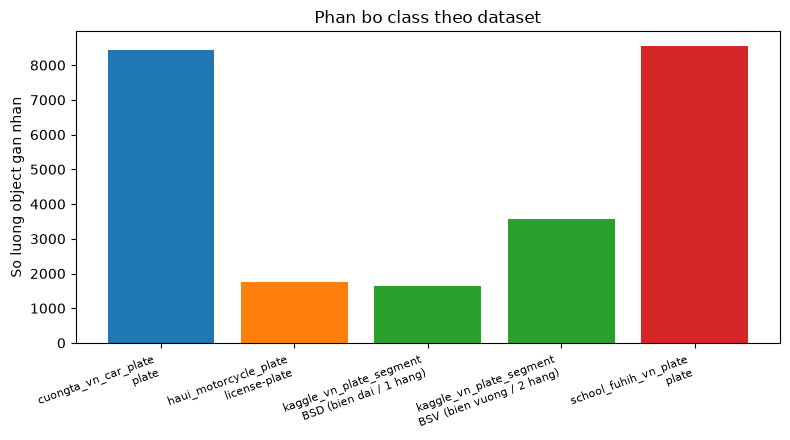

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (key, sub) in enumerate(class_counts.groupby("dataset")):
    ax.bar(
        [f"{key}\n{n}" for n in sub["class_name"]],
        sub["num_objects"],
        label=DATASETS[key]["label"],
    )
ax.set_ylabel("So luong object gan nhan")
ax.set_title("Phan bo class theo dataset")
plt.xticks(rotation=20, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_class_distribution.png", dpi=150)
plt.show()


## 5. Kích thước ảnh & tỉ lệ khung hình (mẫu ngẫu nhiên mỗi dataset)

Đọc hết ~14.7k ảnh bằng OpenCV thì lâu, nên lấy mẫu ngẫu nhiên (seed cố định = 42) mỗi dataset để ước lượng phân bố kích thước và độ sáng thôi, không cần đọc hết.

In [10]:
SAMPLE_N = 600
pixel_rows = []
for key, cfg in DATASETS.items():
    pairs = ALL_PAIRS[key]
    sample = random.sample(pairs, min(SAMPLE_N, len(pairs)))
    for split, img_path, lbl_path in sample:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        pixel_rows.append({
            "dataset": key,
            "split": split,
            "width": w,
            "height": h,
            "aspect_ratio": w / h,
            "mean_brightness": float(gray.mean()),
            "std_brightness": float(gray.std()),
        })

pixel_df = pd.DataFrame(pixel_rows)
pixel_df.groupby("dataset")[["width", "height", "aspect_ratio"]].agg(["min", "max", "mean", "std"])


width                               height        \
                          min   max        mean         std    min   max   
dataset                                                                    
cuongta_vn_car_plate      240  2000  496.473333  109.270945    160  1500   
haui_motorcycle_plate     472   472  472.000000    0.000000    303   303   
kaggle_vn_plate_segment   380  4032  445.773333  335.956833    285  3024   
school_fuhih_vn_plate     640   640  640.000000    0.000000    640   640   

                                                aspect_ratio            \
                               mean         std          min       max   
dataset                                                                  
cuongta_vn_car_plate     321.266667   77.432995     1.250000  1.778976   
haui_motorcycle_plate    303.000000    0.000000     1.557756  1.557756   
kaggle_vn_plate_segment  363.031667  267.046620     0.748333  1.388889   
school_fuhih_vn_plate    640.000000    0.000000     1.000000  1.000000   

                                             
                             mean       std  
dataset                                      
cuongta_vn_car_plate     1.549772  0.052353  
haui_motorcycle_plate    1.557756  0.000000  
kaggle_vn_plate_segment  1.271227  0.180251  
school_fuhih_vn_plate    1.000000  0.000000

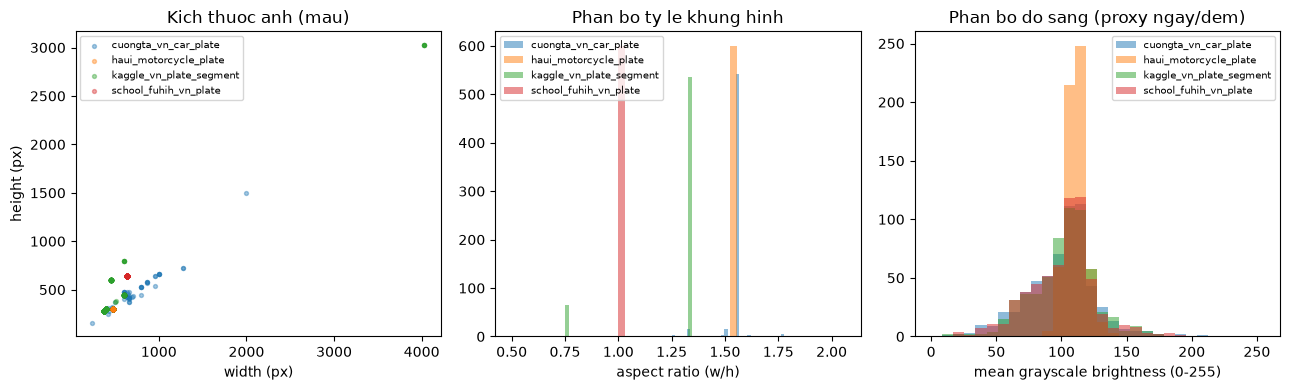

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for key, sub in pixel_df.groupby("dataset"):
    axes[0].scatter(sub["width"], sub["height"], s=8, alpha=0.4, label=key)
axes[0].set_xlabel("width (px)")
axes[0].set_ylabel("height (px)")
axes[0].set_title("Kich thuoc anh (mau)")
axes[0].legend(fontsize=7)

for key, sub in pixel_df.groupby("dataset"):
    axes[1].hist(sub["aspect_ratio"], bins=30, alpha=0.5, label=key)
axes[1].set_xlabel("aspect ratio (w/h)")
axes[1].set_title("Phan bo ty le khung hinh")
axes[1].legend(fontsize=7)

for key, sub in pixel_df.groupby("dataset"):
    axes[2].hist(sub["mean_brightness"], bins=30, alpha=0.5, label=key, range=(0, 255))
axes[2].set_xlabel("mean grayscale brightness (0-255)")
axes[2].set_title("Phan bo do sang (proxy ngay/dem)")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_size_brightness.png", dpi=150)
plt.show()


## 6. Độ sáng — proxy điều kiện ánh sáng ngày/đêm

Không dataset nào có nhãn ánh sáng thật (đã kiểm tra ở phần khảo sát nguồn rồi), nên tạm dùng độ sáng trung bình ảnh xám (0–255) làm proxy: `<70` = tối/thiếu sáng, `70–190` = bình thường, `>190` = rất sáng. Đây chỉ là ước lượng gần đúng thôi, không thay được cho nhãn ánh sáng thật.

In [12]:
def bucket(b):
    if b < 70:
        return "toi/thieu sang"
    if b > 190:
        return "rat sang"
    return "binh thuong"

pixel_df["lighting_bucket"] = pixel_df["mean_brightness"].apply(bucket)
lighting_pct = (
    pixel_df.groupby("dataset")["lighting_bucket"]
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
).round(1)
lighting_pct


lighting_bucket,binh thuong,rat sang,toi/thieu sang
dataset,,,
cuongta_vn_car_plate,85.8,0.5,13.7
haui_motorcycle_plate,100.0,0.0,0.0
kaggle_vn_plate_segment,89.3,0.0,10.7
school_fuhih_vn_plate,87.0,0.2,12.8


## 7. Diện tích biển số tương đối (bbox/polygon area ratio)

Tỉ lệ diện tích vùng biển số / diện tích ảnh, dùng để đoán ảnh là cận cảnh biển số hay chụp xa (toàn cảnh xe/bãi xe).

In [13]:
area_stats = class_df.groupby("dataset")["box_area_ratio"].describe()
area_stats


,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
cuongta_vn_car_plate,8445.0,0.027734,0.024488,0.000210,0.011600,0.023270,0.041604,0.470354
haui_motorcycle_plate,1748.0,0.039012,0.007351,0.018098,0.034541,0.039573,0.043900,0.062964
kaggle_vn_plate_segment,5200.0,0.043249,0.051604,0.000082,0.015787,0.034810,0.051729,0.767362
school_fuhih_vn_plate,8548.0,0.027821,0.024407,0.000211,0.011693,0.023500,0.041653,0.470215


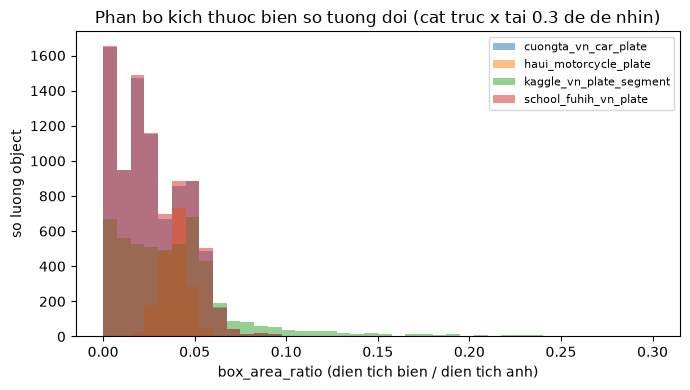

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for key, sub in class_df.groupby("dataset"):
    ax.hist(sub["box_area_ratio"], bins=40, alpha=0.5, label=key, range=(0, 0.3))
ax.set_xlabel("box_area_ratio (dien tich bien / dien tich anh)")
ax.set_ylabel("so luong object")
ax.set_title("Phan bo kich thuoc bien so tuong doi (cat truc x tai 0.3 de de nhin)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_plate_area_ratio.png", dpi=150)
plt.show()


## 8. Ảnh mẫu minh họa bối cảnh

Mở thử vài ảnh mẫu mỗi dataset để xem bằng mắt bối cảnh chụp (cận cảnh biển số / toàn cảnh xe / đường phố / bãi xe) — cái này mô tả text trên trang nguồn không cho biết được.

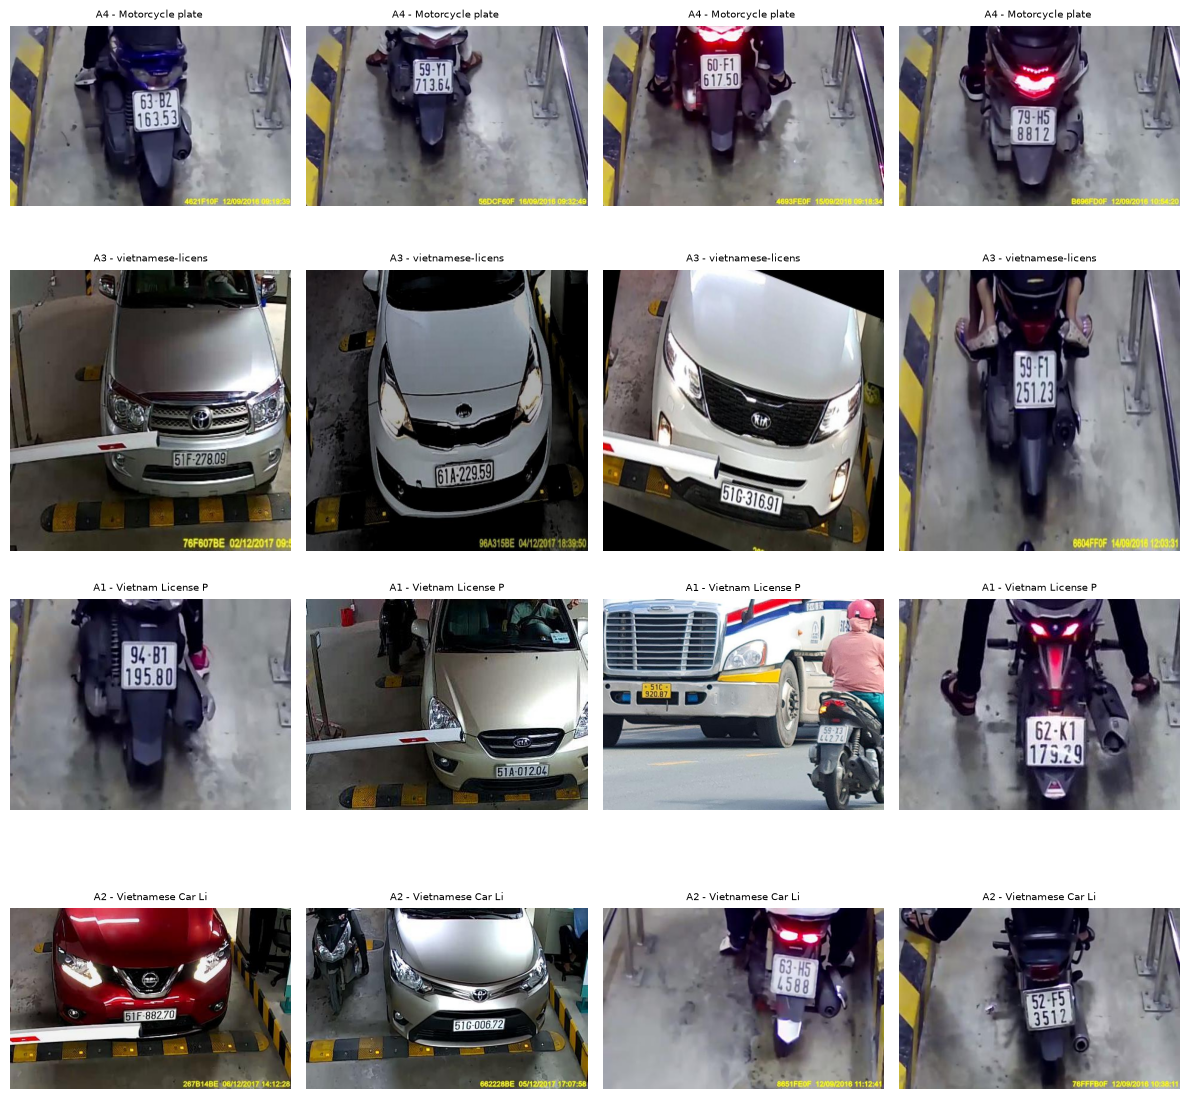

In [15]:
n_datasets = len(DATASETS)
fig, axes = plt.subplots(n_datasets, 4, figsize=(12, 3 * n_datasets))
for row, (key, cfg) in enumerate(DATASETS.items()):
    pairs = ALL_PAIRS[key]
    sample = random.sample(pairs, min(4, len(pairs)))
    for col, (split, img_path, _) in enumerate(sample):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{cfg['label'][:22]}", fontsize=7)
        axes[row, col].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_sample_context.png", dpi=150)
plt.show()


## 9. Bảng tổng hợp EDA

In [16]:
summary_rows = []
for key, cfg in DATASETS.items():
    n_images = split_pivot.loc[key, "total"] if key in split_pivot.index else 0
    n_objects = int(class_df[class_df["dataset"] == key].shape[0])
    px = pixel_df[pixel_df["dataset"] == key]
    lb = lighting_pct.loc[key] if key in lighting_pct.index else None
    summary_rows.append({
        "dataset": key,
        "label": cfg["label"],
        "license": cfg["license"],
        "n_images": int(n_images),
        "n_classes": len(cfg["class_names"]),
        "n_objects_labeled": n_objects,
        "resolution_range": f"{px['width'].min()}-{px['width'].max()} x {px['height'].min()}-{px['height'].max()}",
        "mean_brightness": round(px["mean_brightness"].mean(), 1),
        "pct_dark": round(lb.get("toi/thieu sang", 0.0), 1) if lb is not None else None,
        "mean_box_area_ratio": round(class_df[class_df["dataset"] == key]["box_area_ratio"].mean(), 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / "eda_summary.csv", index=False)
summary_df


,dataset,label,license,n_images,n_classes,n_objects_labeled,resolution_range,mean_brightness,pct_dark,mean_box_area_ratio
0,haui_motorcycle_plate,A4 - Motorcycle plate (HaUI),MIT,1748,1,1748,472-472 x 303-303,111.1,0.0,0.0390
1,school_fuhih_vn_plate,A3 - vietnamese-license-plate (school-fuhih),CC BY 4.0,8357,1,8548,640-640 x 640-640,100.7,12.8,0.0278
2,kaggle_vn_plate_segment,"A1 - Vietnam License Plate Segment (Kaggle, du...",Unknown (verify with author),4578,2,5200,380-4032 x 285-3024,102.1,10.7,0.0432
3,cuongta_vn_car_plate,A2 - Vietnamese Car License Plate (Cuong Ta),Public Domain (CC0),8254,1,8445,240-2000 x 160-1500,100.0,13.7,0.0277


## 10. Nhận xét

- A4 (HaUI) và A3 (school-fuhih) bị Roboflow resize về đúng 1 kích thước khi export (472×303 cho A4, 640×640 cho A3 — std = 0 trong bảng mục 5), nên độ phân giải gốc coi như mất. A1 (Kaggle) và A2 (Cuong Ta) thì không bị resize, vẫn giữ kích thước gốc đa dạng (A1: 380–4032 px, A2: 240–2000 px) — vậy không phải cứ export từ Roboflow là bị resize, tùy dataset.
- Không dataset nào có tỉ lệ ảnh tối/đêm đáng kể: A4 gần như 100% rơi vào mức "bình thường", còn A1/A2/A3 đều chỉ khoảng 11–14% rơi vào mức "tối" (A2: 13,7%, A1: 10,7%, A3: 12,8%). Khớp với nhận định lúc khảo sát nguồn: chưa dataset công khai nào bao phủ đủ điều kiện ban đêm cho camera cổng bãi xe.
- A1 có 2 class tách 1 hàng/2 hàng (BSD/BSV) nhưng bị lệch (BSV 3.559 nhiều hơn BSD 1.641 khoảng 2,2 lần) — nếu gộp các dataset để train thì nên để ý điểm này.
- Xem ảnh mẫu mục 8 xác nhận đúng nhận xét ban đầu về A2: dataset này có cả ô tô (Toyota, Nissan, Kia) lẫn xe máy tại cùng bối cảnh camera cổng bãi xe, không chỉ thiên về ô tô như tên gọi "Car License Plate" gợi ý. A1 cũng xuất hiện cả xe tải trong ảnh mẫu (biển "51C"), thêm một loại xe nữa ngoài ô tô con/xe máy.
- Diện tích biển số tương đối (mục 7) khá nhỏ ở cả 4 bộ (0,028–0,043, median thấp), tức đa số ảnh là toàn cảnh xe/đường phố chứ không phải cận cảnh sát biển số như góc camera dự kiến lắp trên Pi 5.

Feeds into: chương "Thu thập và xử lý dữ liệu" (Tuần 2) — số liệu ở đây dùng để viết phần phân tích dataset trong báo cáo, thay vì chỉ dựa mô tả trang nguồn. A1/A2 còn là căn cứ cho quyết định riêng về dataset detect vùng biển số (xem `docs/research/2026-07-30-parking-vehicle-plate-datasets.md`, mục A).
